# Revised and In-Progress with Code Enhancements

    As of now, after fitting the model, we observe the results visually through plots to assess how well the model has been trained so far.

1.	**Simple Linear Regression:**

  1)	**Single Input:** You use only one independent feature (input variable) to predict the dependent variable (target).

  2)	Example: Predicting salary based on years of experience.

2.	**Multiple Linear Regression:**

  1)	**Multiple Features:** You use multiple independent features (input variables) to predict the dependent variable (target).

  2)	Example: Predicting salary based on years of experience, test score, and interview score.

**Single Input** → Simple Linear Regression

**Multiple Features** → Multiple Linear Regression  



In [ ]:
# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown, HTML

# Track the time when the first cell is executed
first_cell_time = datetime.now()

# Set IST timezone (Indian Standard Time)
ist = timezone('Asia/Kolkata')

# Get the current time in IST for the first cell entry
current_time_ist_first = datetime.now(ist).strftime('%Y-%m-%d %H:%M:%S')

# Display the statement "This is the first cell" in green and bold
display(HTML("<p style='color:green; font-weight:bold;'>This is the first cell. Initialization and setup are done below:</p>"))

# Display the current IST time for the first cell in bold (default color)
display(Markdown(f'**First Cell Entry Time: {current_time_ist_first}**'))


**First Cell Entry Time: 2025-06-16 18:38:38**

In [ ]:
# Importing the libraries
import pandas as pd

In [ ]:
# Reading a CSV file from a URL into a pandas DataFrame
dataset = pd.read_csv('https://raw.githubusercontent.com/9394113857/Predict-Salary-Analysis/raghu/hiring.csv')

In [ ]:
# Displaying the shape (dimensions) of the dataset: (number of rows, number of columns)
# 'shape' is an attribute, not a method, so no parentheses are needed. It returns a tuple like (100, 5).
dataset.shape  # Returns the number of rows and columns as a tuple (e.g., (100, 5))


(8, 4)

**Method** = **Needs** parentheses **()**, **may expect arguments**, and usually performs an action (**e.g., modifies, calculates**).

**Attribute** = **No** parentheses (), **does not expect arguments**, and simply **gives information about the object**.

In [ ]:
# Printing entire dataset
dataset

,experience,test_score,interview_score,salary
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


# EDA:-

**EDA** (Exploratory Data Analysis) is an essential process or flow in any Machine Learning (ML) task.

**EDA** in the ML Process:

1.	Understand the Data:
o	Before building any machine learning model, you need to understand the structure, patterns, and distributions of the data.
o	Steps: Check the number of features, data types, missing values, and overall dataset size.
o	For Supervised Learning: Check for the target variable (labels), whether it's categorical or continuous.
o	For Unsupervised Learning: Analyze feature distributions and relationships, as there may not be a target variable.
2.	Identify Patterns and Trends:
o	EDA helps identify relationships, trends, and patterns that can inform feature selection or engineering.
o	Steps: Visualize correlations between features, detect trends or seasonality, and spot outliers.
o	For Supervised Learning: Investigate how features correlate with the target variable.
o	For Unsupervised Learning: Look for hidden patterns, clusters, or distributions in the data.
3.	Data Cleaning and Preprocessing:
o	EDA helps identify outliers, missing values, and any inconsistencies, which can then be addressed.
o	Steps: Handle missing data, fix errors, detect and remove outliers, and normalize features.
o	For Supervised Learning: Ensure that the target variable is clean and appropriately encoded.
o	For Unsupervised Learning: Focus on cleaning input features to ensure accurate clustering or dimensionality reduction.
4.	Feature Engineering:
o	Insights from EDA can lead to creating new features that may improve model performance.
o	Steps: Create new features based on domain knowledge or visual patterns, encode categorical variables, and scale/normalize numerical features.
o	For Supervised Learning: Focus on creating features that help the model predict the target variable better.
o	For Unsupervised Learning: Focus on creating features that can help uncover hidden structures or relationships within the data.
5.	Informing Modeling Decisions:
o	EDA helps guide the choice of algorithms and their hyperparameters.
o	Steps: Based on data distribution and patterns, decide on the appropriate model (e.g., linear vs. non-linear).
o	For Supervised Learning: Choose between regression, classification, or ensemble models, and tune hyperparameters based on insights from the data.
o	For Unsupervised Learning: Choose between clustering algorithms (e.g., K-Means, DBSCAN) or dimensionality reduction techniques (e.g., PCA, t-SNE).
________________________________________
Overall Steps in EDA for Supervised & Unsupervised Learning:
1.	Understand the Data: Check structure, data types, and distribution of features.
2.	Identify Patterns and Trends: Visualize and detect relationships, correlations, and outliers.
3.	Data Cleaning and Preprocessing: Handle missing data, fix errors, and clean outliers.
4.	Feature Engineering: Create new features or transform existing ones based on insights.
5.	Inform Modeling Decisions: Choose appropriate models and hyperparameters based on data characteristics.
________________________________________
Summary:
1.	**Supervised Learning:** Focuses on understanding how features relate to the target variable, and ensuring the target is clean and properly encoded.

2.	**Unsupervised Learning:** Focuses on understanding patterns in the data without a target, with an emphasis on finding structure or clusters in the features.

This combined view covers the overall EDA flow and steps applicable to both types of ML tasks, helping guide the data preparation phase for both supervised and unsupervised learning.
Let me know if this is helpful or if you need further details!




In [ ]:
# Printing the entire DataFrame since it's small
# Since this is a small dataset, it will print the entire DataFrame.
print(dataset)

# If the dataset were larger, pandas would show the first 5 rows and the last 5 rows by default.
# For example, calling dataset.head() will show the first 5 rows, and dataset.tail() will show the last 5 rows.

  experience  test_score  interview_score  salary
0        NaN         8.0                9   50000
1        NaN         8.0                6   45000
2       five         6.0                7   60000
3        two        10.0               10   65000
4      seven         9.0                6   70000
5      three         7.0               10   62000
6        ten         NaN                7   72000
7     eleven         7.0                8   80000


In [ ]:
dataset  # This will show the entire dataset since it's small

,experience,test_score,interview_score,salary
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [ ]:
from tabulate import tabulate  # Importing tabulate for formatted table output

# Dynamically fetching column names and their data types
column_info = pd.DataFrame({
    'Sno': range(1, len(dataset.columns) + 1),  # Serial number for each column
    'Column Name': dataset.columns,             # Extracting column names dynamically
    'Data Type': [dataset[col].dtype for col in dataset.columns]  # Extracting data types dynamically
})

# Displaying the column names and their data types with borders
print("\nColumn Data Types in Tabular Format:")
# Using tabulate to display the DataFrame in a well-formatted table with borders
print(tabulate(column_info, headers='keys', tablefmt='grid', showindex=False))


Column Data Types in Tabular Format:
+-------+-----------------+-------------+
|   Sno | Column Name     | Data Type   |
+=======+=================+=============+
|     1 | experience      | object      |
+-------+-----------------+-------------+
|     2 | test_score      | float64     |
+-------+-----------------+-------------+
|     3 | interview_score | int64       |
+-------+-----------------+-------------+
|     4 | salary          | int64       |
+-------+-----------------+-------------+


In [ ]:
dataset  # This will show the entire dataset since it's small

,experience,test_score,interview_score,salary
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [ ]:
# Replacing null values with zero in the 'experience' column
# - 'dataset['experience']' refers to the 'experience' column in the dataset.
# - '.fillna(0)' is a function that replaces all missing values (NaN) in the column with the specified value, which is 0 in this case.
# - 'inplace=True' makes the change directly in the original DataFrame without the need to assign it to a new variable.
dataset['experience'].fillna(0, inplace=True)

# Replacing null values with the mean of 'test_score' in the 'test_score' column
# - 'dataset['test_score']' refers to the 'test_score' column in the dataset.
# - '.mean()' calculates the mean (average) value of all the non-null values in the 'test_score' column.
# - '.fillna(dataset['test_score'].mean())' replaces any missing values (NaN) in the 'test_score' column with the calculated mean.
# - 'inplace=True' ensures the modification is done directly in the original DataFrame, updating the missing values in place.
dataset['test_score'].fillna(dataset['test_score'].mean(), inplace=True)


<ipython-input-10-7182a26adc12>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['experience'].fillna(0, inplace=True)
<ipython-input-10-7182a26adc12>:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [ ]:
# Again checking if changes applied or not: 'experience' column should have 0 for missing values,
# and 'test_score' column should have the mean (8.0) for missing values.
dataset  # 'experience' column has 0 for missing values, 'test_score' column has 8.0 for missing values


,experience,test_score,interview_score,salary
0,0,8.000000,9,50000
1,0,8.000000,6,45000
2,five,6.000000,7,60000
3,two,10.000000,10,65000
4,seven,9.000000,6,70000
5,three,7.000000,10,62000
6,ten,7.857143,7,72000
7,eleven,7.000000,8,80000


**Note:-**


Actual "dataset" values changed inthose of Nan with as our required whatever accordingly in specifiec columns those values accordingly we changed for the actual dataset called "**dataset**"


# Write steps here changes are applied but points not placed accordigly for understanding what has done like that to the dataframe okay.

After changes applied to the actual "**dataset**" we seperate the featues portion assign it to **X**

In [ ]:
# Extracting the values of all rows and the first three columns from the DataFrame 'dataset' and assigning it to 'X'
X = dataset.iloc[:, :3]
X

,experience,test_score,interview_score
0,0,8.000000,9
1,0,8.000000,6
2,five,6.000000,7
3,two,10.000000,10
4,seven,9.000000,6
5,three,7.000000,10
6,ten,7.857143,7
7,eleven,7.000000,8


In [ ]:
print(type(X))

<class 'pandas.core.frame.DataFrame'>


(A)	**dataset.iloc[:, :3]:**

1) **dataset:** Refers to the original DataFrame containing your data.

2)	**.iloc:** A pandas method for indexing, used to select rows and columns by integer position.

3)  **:** Selects all rows from left argument.

4)	**:3** Selects the first 3 columns (columns at index **0, 1,** and **2**).

(B)	**X = dataset.iloc[:, :3]:**

1)	Extracts all rows and the first 3 columns from dataset.

•	The result is a new DataFrame assigned to the variable X.

(C)	**Result:**

1)	X is now a new DataFrame containing the first three columns of dataset.

2)	The type of X is <class 'pandas.core.frame.DataFrame'>, meaning it's a DataFrame object.



In [ ]:
# ***

In [ ]:
# Function to convert words to integer values
def convert_to_int(word):
    # Defining a dictionary that maps word strings (like 'one', 'two', etc.) to their corresponding integer values
    word_dict = {'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'seven': 7, 'eight': 8,
                 'nine': 9, 'ten': 10, 'eleven': 11, 'twelve': 12, 'zero': 0, 0: 0}

    # Returning the corresponding integer value from the dictionary using the input word
    return word_dict[word]


The function **convert_to_int** takes a word **(like 'five', 'ten', etc.)** as input and **returns the corresponding integer value** based on the dictionary it uses.

# In simpler terms:

1. If you pass a word (like 'five') to the function, it will return the integer value (like 5).

2. The function is essentially looking up the integer value associated with that word in the word_dict dictionary and returning it.

**For example:**

convert_to_int('five') will return 5.

convert_to_int('ten') will return 10.

convert_to_int('zero') will return 0.

**Summary:**

So, the function **returns the integer value that corresponds to the input word.**

In [ ]:
X # since inital changes once we see nwo before appliyng the new changes in 'experience' column}

,experience,test_score,interview_score
0,0,8.000000,9
1,0,8.000000,6
2,five,6.000000,7
3,two,10.000000,10
4,seven,9.000000,6
5,three,7.000000,10
6,ten,7.857143,7
7,eleven,7.000000,8


In [ ]:
# Applying the convert_to_int function to the 'experience' column in DataFrame 'X'
X['experience'] = X['experience'].apply(lambda x: convert_to_int(x))


**Code Points:**

1.	**Select the experience column:** X['experience'] refers to the experience column in the DataFrame X.
2.	**Apply the convert_to_int function:** .apply(lambda x: convert_to_int(x)) applies the convert_to_int function to each value in the experience column. The lambda x is a simple function that takes each value (x) and passes it to convert_to_int(x).
3.	**Update the experience column:** The converted integer values are assigned back to the experience column in the DataFrame X, replacing the original words with numbers.



1.	**Load the experience column:** The entire experience column from the DataFrame X is loaded.
2.	**Detect and Convert Words:** Each word (like 'five', 'ten') is detected and passed to the convert_to_int function, which maps words to numbers (e.g., 'five' → 5).
3.	**Update the experience column:** The original words are replaced with their respective integer values in the experience column, updating the dataset.



In [ ]:
X # Now we see thsoe changes applied as how we want accordinglly okay.

,experience,test_score,interview_score
0,0,8.000000,9
1,0,8.000000,6
2,5,6.000000,7
3,2,10.000000,10
4,7,9.000000,6
5,3,7.000000,10
6,10,7.857143,7
7,11,7.000000,8


In [ ]:
# Extracting the values of all rows and the last column from the DataFrame 'dataset' and assigning it to 'y'
y = dataset.iloc[:, -1]


In [ ]:
y

,salary
0,50000
1,45000
2,60000
3,65000
4,70000
5,62000
6,72000
7,80000


Continue

In [ ]:
# Importing the LinearRegression class from scikit-learn's linear_model module
from sklearn.linear_model import LinearRegression

# Creating an instance of the Linear Regression model and assigning it to the variable 'regressor'
model = LinearRegression()  # This 'regressor' object will be used to fit the model and make predictions


In [ ]:
# Fitting the Linear Regression model using the training data (X for features and y for target)
model.fit(X, y)  # This trains the model by finding the best-fitting line to the data in X and y


LinearRegression()

1.	**Fitting the Model:** The fit() method is used to train the linear regression model.

  It takes two arguments:

  •	X: This represents the input features (independent variables).
  
  •	y: This represents the target values (dependent variable), which the model tries to predict.
2.	**Training the Model:** When you call regressor.fit(X, y), the model learns the relationship between the features (X) and the target values (y).

  It does this by finding the coefficients (slope and intercept) that best fit a linear equation to the data.



In [ ]:
# Calculate the accuracy score of the Linear Regression model on the training data
model.score(X, y)  # This returns the R² (R-squared) value, which measures how well the model fits the data


0.9639958361860579

1.	**regressor.score(X, y):**
o	This method calculates the R² score (coefficient of determination) of the model on the training data.
o	X: The input features (independent variables).
o	y: The actual target values (dependent variable).

2.	**R² Score:**
o	The R² score tells you how well the model's predictions match the actual data.
o	An R² value of 1 means perfect predictions, while a value of 0 means the model does not explain any of the variability in the data.
o	In this case, 0.9639958361860579 means the model explains 96.4% of the variance in the target variable y, which is a very good fit.



The score() method in the context of a Linear Regression model helps evaluate how well the model fits the data. Here's how the R² score (coefficient of determination) helps you understand the model's fit:

1. **What Does the Score Mean?**
•	The R² score is a statistical measure that tells you how well the model's predictions match the actual data.
•	It indicates the proportion of the variance in the dependent variable (y) that is predictable from the independent variables (X).
2. **Interpreting the Score:**
•	R² = 1: The model perfectly predicts the target variable. All the data points lie exactly on the predicted line.
•	R² = 0: The model does not explain any of the variance in the target variable. It’s no better than predicting the mean value of the target variable.
•	R² between 0 and 1: The closer the value is to 1, the better the model fits the data. For example:
o	R² = 0.96: The model explains 96% of the variance in the data, which is a very good fit.
o	R² = 0.5: The model explains 50% of the variance, which is considered a moderate fit.
3. **How the Score Shows Data Fit:**
•	High R² (close to 1): If the R² score is close to 1 (like 0.96 in your case), it means the model is doing a good job at fitting the data and making predictions.
•	Low R² (close to 0): If the R² score is close to 0, it indicates the model does not capture the underlying trends in the data well.

**In your case:**

•	The score 0.9639958361860579 means that 96.4% of the variance in the target variable y is explained by the model, which indicates that your model is a very good fit for the data.

In simpler terms, by checking the R² score, you're assessing how well your linear regression model is capturing the relationship between the features (X) and the target (y). The higher the score, the better the model's predictions align with the actual values.





In [ ]:
import matplotlib.pyplot as plt

# Assuming the model is already fitted, and predictions are available

# Plotting the actual data points and regression predictions
plt.figure(figsize=(10, 6))

# Scatter plot of the actual data points
plt.scatter(X[:, 0], y, color='red', label='Actual Salary', alpha=0.7)  # Experience vs Salary

# Plot the regression line based on the model's predictions
plt.plot(X[:, 0], predictions, color='black', label='Predicted Salary')

# Titles and labels for the plot
plt.title('Salary Prediction Based on Experience, Test Score, and Interview Score', fontsize=14)
plt.xlabel('Experience (Years)', fontsize=12)
plt.ylabel('Salary', fontsize=12)

# Add a legend
plt.legend()

# Display the plot
plt.show()


InvalidIndexError: (slice(None, None, None), 0)

<Figure size 1000x600 with 0 Axes>

**Features and Target:**

•	**Features:**

o	Experience (X[:, 0])

o	Test Score (X[:, 1])

o	Interview Score (X[:, 2])

•	**Target:**

o	Salary (y)

While the model uses **Experience, Test Score, and Interview Score** to predict **Salary**, the plot shown only represents the relationship between **Experience** and **Salary** in a **2D space**, since visualizing all three features in a 2D plot would be **impossible**.

The **regression line shows** how the model predicts Salary based on all **three features**, but the plot itself visualizes only the impact of **Experience**.



In a 3D space, you can plot the three features against the target variable to see how they together influence the salary.

InvalidIndexError: (slice(None, None, None), 0)

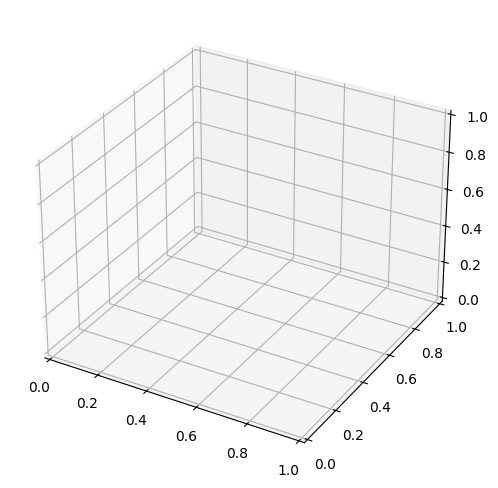

In [ ]:
# Cell 1: 3D Scatter Plot of Actual Salary vs Features

from mpl_toolkits.mplot3d import Axes3D  # Importing 3D plotting tools from Matplotlib
import matplotlib.pyplot as plt  # Importing Matplotlib for plotting

# Step 1: Create a 3D scatter plot
fig = plt.figure(figsize=(10, 6))  # Set the figure size to 10x6 inches
ax = fig.add_subplot(111, projection='3d')  # Add a 3D subplot to the figure

# Step 2: Plot actual data points in 3D space
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis', label='Actual Salary', alpha=0.7)
# X[:, 0] -> Experience, X[:, 1] -> Test Score, X[:, 2] -> Interview Score
# y -> Actual Salary, `c=y` color points based on salary, `cmap='viridis'` sets color map

# Step 3: Label axes
ax.set_xlabel('Experience (Years)')  # Label the x-axis as Experience (Years)
ax.set_ylabel('Test Score')  # Label the y-axis as Test Score
ax.set_zlabel('Interview Score')  # Label the z-axis as Interview Score

# Step 4: Add plot title
ax.set_title('3D Scatter Plot of Actual Salary vs Features')  # Title of the plot

# Step 5: Display the plot
plt.legend()  # Add a legend to differentiate actual salary points
plt.show()  # Show the plot

# **Key Points of the Plot**:
# 1. **Actual Salary** is visualized in 3D space against the three features: **Experience**, **Test Score**, and **Interview Score**.
# 2. The points are color-coded based on **Salary** using a color map (`viridis`), showing the salary distribution.
# 3. The plot helps to understand how the salary data is distributed across different feature values and their relationships.


InvalidIndexError: (slice(None, None, None), 0)

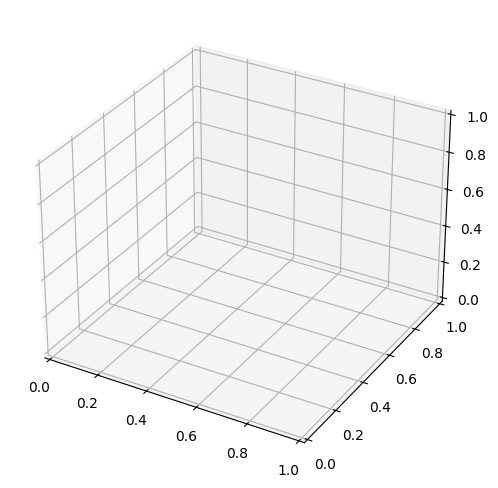

In [ ]:
# Cell 2: 3D Surface Plot of Predicted Salary vs Features

from mpl_toolkits.mplot3d import Axes3D  # Importing 3D plotting tools from Matplotlib
import numpy as np  # Importing NumPy for numerical operations
import matplotlib.pyplot as plt  # Importing Matplotlib for plotting

# Step 1: Create a 3D surface plot
fig = plt.figure(figsize=(10, 6))  # Set the figure size to 10x6 inches
ax = fig.add_subplot(111, projection='3d')  # Add a 3D subplot to the figure

# Step 2: Create a mesh grid for the features (Experience and Test Score)
x = np.linspace(min(X[:, 0]), max(X[:, 0]), 100)  # Create an array of Experience values
y = np.linspace(min(X[:, 1]), max(X[:, 1]), 100)  # Create an array of Test Score values
x, y = np.meshgrid(x, y)  # Create a mesh grid for plotting

# Step 3: Predict salary for each point in the mesh grid
z = model.predict(np.c_[x.ravel(), y.ravel(), np.zeros_like(x.ravel())])  # Predict salary using the model, setting Interview Score to 0
z = z.reshape(x.shape)  # Reshape the predictions to match the mesh grid

# Step 4: Plot the surface
ax.plot_surface(x, y, z, cmap='viridis', alpha=0.5)  # Plot the surface with a color map for visual effect

# Step 5: Label axes
ax.set_xlabel('Experience (Years)')  # Label the x-axis as Experience (Years)
ax.set_ylabel('Test Score')  # Label the y-axis as Test Score
ax.set_zlabel('Predicted Salary')  # Label the z-axis as Predicted Salary

# Step 6: Add plot title
ax.set_title('3D Surface Plot of Predicted Salary vs Features')  # Title of the plot

# Step 7: Display the plot
plt.show()  # Show the plot

# **Key Points of the Plot**:
# 1. **Predicted Salary** is visualized in a 3D surface plot against **Experience** and **Test Score**.
# 2. The plot uses a **mesh grid** of **Experience** and **Test Score**, while **Interview Score** is set to 0 for simplicity.
# 3. This surface plot helps understand the relationship between features and predicted salary, showing how predicted salaries change as the features vary.


Shape of X: (8, 3)
Shape of y: (8,)


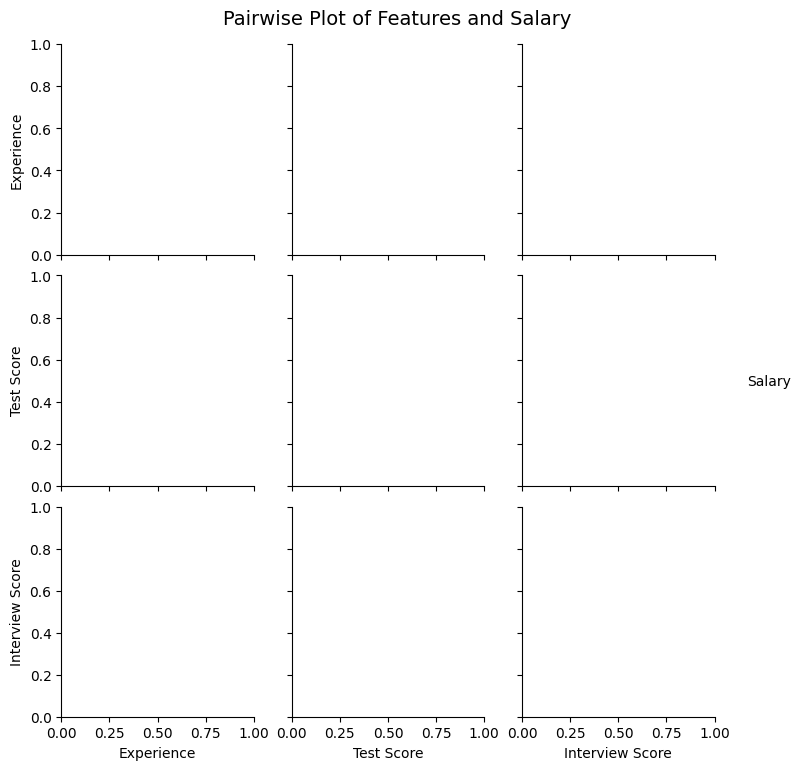

In [ ]:
# Cell 3: Pairwise Plot of Features and Salary

import seaborn as sns  # Importing Seaborn for advanced plotting
import pandas as pd  # Importing Pandas for handling data structures
import matplotlib.pyplot as plt  # Importing Matplotlib for plotting

# Step 1: Verify the shapes of X and y
print("Shape of X:", X.shape)  # Checking the shape of the feature matrix X
print("Shape of y:", y.shape)  # Checking the shape of the target variable y

# If y has more than 1 dimension, reshape it to be 1D (if needed)
if y.ndim > 1:
    y = y.reshape(-1)  # Flatten y to make it 1D

# Ensure that X and y have the same number of rows (samples)
if X.shape[0] != len(y):
    raise ValueError("Mismatch in number of samples between X and y. Please check your data.")

# Step 2: Create a DataFrame with the features and target variable (Salary)
data = pd.DataFrame(X, columns=['Experience', 'Test Score', 'Interview Score'])  # Create DataFrame for features
data['Salary'] = y  # Add target variable (Salary) to the DataFrame

# Step 3: Plot pairwise relationships between features and target variable (Salary)
sns.pairplot(data, hue='Salary', palette='viridis')  # Pairwise plot with Salary as hue for color coding

# Step 4: Add plot title
plt.suptitle('Pairwise Plot of Features and Salary', y=1.02, fontsize=14)  # Title of the plot

# Step 5: Display the plot
plt.show()  # Show the plot

# **Key Points of the Plot**:
# 1. The **Pairwise Plot** visualizes pairwise relationships between the features (**Experience**, **Test Score**, **Interview Score**) and **Salary**.
# 2. Each scatter plot shows how two features correlate with each other, with **Salary** color-coded to help visualize its relationship.
# 3. The diagonal histograms show the distribution of each feature, while the scatter plots highlight potential correlations between them.


In [ ]:
X # These are the inputs we have to give to model when the model is loaded ok.

,experience,test_score,interview_score
0,0,8.000000,9
1,0,8.000000,6
2,5,6.000000,7
3,2,10.000000,10
4,7,9.000000,6
5,3,7.000000,10
6,10,7.857143,7
7,11,7.000000,8


In [ ]:
# These are y single outcome y is test results, we have given first x as train data,
# then y is test data we are looking the samples okay,
# but check actual predicted model results would near to the test results means we achieved our use-case ok.
y

,salary
0,50000
1,45000
2,60000
3,65000
4,70000
5,62000
6,72000
7,80000


# Evaluation

Evaluation means the process of assessing or judging the quality, effectiveness, or performance of something. In the context of machine learning, evaluation refers to the process of testing a model's performance to understand how well it makes predictions on unseen data. It involves measuring the model's accuracy, error rates, and other performance metrics to determine how well it generalizes.

**In simpler terms:**

**Evaluation** = Checking how good or bad the model is at predicting or solving a problem.

**Points:-**

1.	Check Predictions with User Inputs: You can input new data manually (e.g., user input) and test the model's predictions before saving the model.
2.	Interactive Testing: This allows you to interactively evaluate how well the model performs on new, unseen data.
3.	No Need for Serialization: You don't have to serialize (save) the model first. You can directly test and make predictions using the trained model without dumping it to a file.



# User Input: Before Saving the model

In [ ]:
# Import necessary libraries
import pickle
from rich.console import Console

# Get user input for experience, test score, and interview score
Value_1 = float(input("Enter Experience | Eg: 2 "))
Value_2 = float(input("Enter Test Score | Eg: 9 "))
Value_3 = float(input("Enter Interview Score | Eg: 6 "))
print()

# Create a Console instance for rich text printing
console = Console()

# Print the section separator
console.print("=================================================")

# Print the entered values in bold green
console.print(f"The entered values: [bold green]{Value_1}[/bold green], [bold green]{Value_2}[/bold green], [bold green]{Value_3}[/bold green]")

# Use the model to predict based on the entered values
predicted = model.predict([[Value_1, Value_2, Value_3]])

# Print the predicted value from the model in bold green
console.print(f"The predicted value from the model: [bold green]{predicted[0]}[/bold green]")

# Print the section separator
console.print("=================================================")


Enter Experience | Eg: 2 


ValueError: could not convert string to float: ''

In [ ]:
# Import the Pickle library
import pickle


In [ ]:
# Save the trained Linear Regression model to a file using Pickle
pickle.dump(model, open('multi_linear_regression_salary_prediction.pkl', 'wb'))


In [ ]:
# Load the saved Linear Regression model for comparison
model = pickle.load(open('multi_linear_regression_salary_prediction.pkl', 'rb'))


In [ ]:
# The variable 'model' holds the loaded Linear Regression model
model


LinearRegression()

In [ ]:
# Print the type of variable 'model'
type(model)


sklearn.linear_model._base.LinearRegression

In [ ]:
# Use the loaded model to make predictions on new data
result = model.predict([[2, 9, 6]])
print(result)


[53290.89255945]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# User Input: After Saving the model

In [ ]:
# Import necessary libraries
import pickle
from rich.console import Console

# Load the pre-trained Linear Regression model
model = pickle.load(open('multi_linear_regression_salary_prediction.pkl', 'rb'))  # Replace 'your_model_path.pkl' with the actual path to your model file

# Get user input for experience, test score, and interview score
Value_1 = float(input("Enter Experience | Eg: 2 "))
Value_2 = float(input("Enter Test Score | Eg: 9 "))
Value_3 = float(input("Enter Interview Score | Eg: 6 "))
print()

# Create a Console instance for rich text printing
console = Console()

# Print the section separator
console.print("=================================================")

# Print the entered values in bold green
console.print(f"The entered values: [bold green]{Value_1}[/bold green], [bold green]{Value_2}[/bold green], [bold green]{Value_3}[/bold green]")

# Use the model to predict based on the entered values
predicted = model.predict([[Value_1, Value_2, Value_3]])

# Print the predicted value from the model in bold green
console.print(f"The predicted value from the model: [bold green]{predicted[0]}[/bold green]")

# Print the section separator
console.print("=================================================")


Enter Experience | Eg: 2 2
Enter Test Score | Eg: 9 9
Enter Interview Score | Eg: 6 6



=================================================

The entered values: 2.0, 9.0, 6.0

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


The predicted value from the model: 53290.892559447646

=================================================

In [ ]:
import pandas as pd

# Creating a DataFrame to present information in table format
regression_summary_table = pd.DataFrame(columns=['SNo', 'Type', 'Task', 'Target Variable', 'Data Type'])

# Adding information for the regression problem with supervised learning
regression_summary_table.loc[0] = [1, 'Supervised Learning', 'Multi-linear Regression', 'Salary', 'Labeled']

# Displaying the information in table format
print(regression_summary_table.to_markdown(index=False, tablefmt="pretty", colalign=("center",)))

+-----+---------------------+-------------------------+-----------------+-----------+
| SNo |        Type         |          Task           | Target Variable | Data Type |
+-----+---------------------+-------------------------+-----------------+-----------+
|  1  | Supervised Learning | Multi-linear Regression |     Salary      |  Labeled  |
+-----+---------------------+-------------------------+-----------------+-----------+


# https://chat.openai.com/c/6dec87ca-c07a-4abf-9b5b-17a9887f6cb2

In [ ]:
# Track the time when the last cell is executed
last_cell_time = datetime.now()

# Get current time in IST for the last cell entry
now_ist_last = datetime.now(ist)

# Format the current date and time for the last cell
formatted_date_last = now_ist_last.strftime('%Y-%m-%d')
formatted_time_last = now_ist_last.strftime('%H:%M:%S %Z%z')

# Display the statement "All cells above have been executed..." in red and bold
display(HTML("<p style='color:red; font-weight:bold;'>All cells above have been executed. Below is the current date and time in IST:</p>"))

# Display the last cell entry time in bold (default color)
display(Markdown(f'**Last Cell Entry Time: {formatted_date_last} {formatted_time_last}**'))


**Last Cell Entry Time: 2024-12-16 12:43:39 IST+0530**

In [ ]:
# Calculate the time difference between first and last cell execution
time_diff = last_cell_time - first_cell_time

# Extract hours, minutes, and seconds from the time difference
hours = time_diff.seconds // 3600  # Total seconds divided by 3600 to get hours
minutes = (time_diff.seconds % 3600) // 60  # Remainder divided by 60 to get minutes
seconds = time_diff.seconds % 60  # Remainder gives the number of seconds

# Display the statement for total time taken in execution in orange and bold
display(HTML("<p style='color:orange; font-weight:bold;'>Total Time Taken for Notebook Execution:</p>"))

# Display the first and last cell entry times along with the total time taken in HH:MM:SS format
display(Markdown(f'**First Cell Entry Time: {current_time_ist_first}**'))
display(Markdown(f'**Last Cell Entry Time: {formatted_date_last} {formatted_time_last}**'))
display(Markdown(f'**Time Taken: {hours} hour(s), {minutes} minute(s), and {seconds} second(s)**'))


**First Cell Entry Time: 2024-12-16 12:43:24**

**Last Cell Entry Time: 2024-12-16 12:43:39 IST+0530**

**Time Taken: 0 hour(s), 0 minute(s), and 14 second(s)**

# Download and load drive process

In [ ]:
import gdown
import os
from rich.console import Console
from rich.text import Text
from datetime import datetime
import pytz  # Import pytz to handle time zones

# Initialize a Console object for rich output
console = Console()

# Define the file ID for the file you want to download from Google Drive
file_id = '1WPlKimujE68NDKDREWSQs4b6--XChKyW'

# Ask the user for the file name to save the downloaded file as, with styled prompt
console.print("[bold magenta]Enter the name to save the file[/bold magenta] [bold cyan](press Enter to use default 'multi_linear_regression_salary_prediction.pkl')[/bold cyan]: ", end="")
output_path = input()  # User input follows the styled prompt

# If no input is provided, use the default output file name
if not output_path:
    output_path = 'multi_linear_regression_salary_prediction.pkl'  # Default file name

# **Separated Output for Clear Visibility**
console.print("\n" + "-" * 60, style="bold magenta")  # Separator for clarity
console.print(f"[bold cyan]The file will be saved as: [bold green]{output_path}[/bold green][/bold cyan]", style="bold yellow")
console.print("-" * 60, style="bold magenta")  # Another separator for better structure

# Create a timezone object for IST (Indian Standard Time)
ist = pytz.timezone('Asia/Kolkata')

# Function to get the current IST time formatted as a string
def get_ist_time():
    now_ist = datetime.now(ist)
    return now_ist.strftime('%Y-%m-%d %H:%M:%S')

# Get the current time and date for the process start in IST
current_time_ist = get_ist_time()

# Check if the file already exists
if os.path.exists(output_path):
    console.print(f"\n[bold yellow]The file [bold green]{output_path}[/bold green] already exists. Skipping download.", style="bold red")
    console.print(f"[bold cyan]Check time: {current_time_ist} (IST)[/bold cyan]", style="bold green")
    console.print("-" * 60, style="bold magenta")  # Separator after the message
else:
    # Get current time and date for download start in IST
    download_start_time_ist = get_ist_time()

    # Informing the user about the download process
    console.print(f"\n[bold yellow]Starting download at {download_start_time_ist} (IST)... Please wait.[/bold yellow]", style="bold blue")
    console.print("-" * 60, style="bold magenta")  # Separator for better visual structure

    try:
        # Use gdown to download the file from Google Drive
        gdown.download(f'https://drive.google.com/uc?id={file_id}', output_path, quiet=False)

        # Get current time and date after the download is complete in IST
        download_end_time_ist = get_ist_time()

        # Notify the user upon successful download
        console.print(f"\n[bold green]Download complete![/bold green] The file is saved as [bold green]{output_path}[/bold green].", style="bold cyan")
        console.print(f"[bold cyan]Download finished at {download_end_time_ist} (IST).[/bold cyan]", style="bold green")
        console.print("-" * 60, style="bold magenta")  # Final separator for better separation

    except Exception as e:
        # If there's an error, show a clear error message
        console.print(f"\n[bold red]Error:[/bold red] An error occurred while downloading the file: {e}", style="bold red")
        console.print("-" * 60, style="bold magenta")  # Separator after error message

Enter the name to save the file (press Enter to use default 'multi_linear_regression_salary_prediction.pkl'):

------------------------------------------------------------

The file will be saved as: multi_linear_regression_salary_prediction.pkl

------------------------------------------------------------

Starting download at 2025-06-17 13:48:47 (IST)... Please wait.

------------------------------------------------------------

Downloading...
From: https://drive.google.com/uc?id=1WPlKimujE68NDKDREWSQs4b6--XChKyW
To: /content/multi_linear_regression_salary_prediction.pkl
100%|██████████| 582/582 [00:00<00:00, 266kB/s]


Download complete! The file is saved as multi_linear_regression_salary_prediction.pkl.

Download finished at 2025-06-17 13:48:50 (IST).

------------------------------------------------------------

# User-Prediction with Saved Model:-

OMIT

# User-Prediction with Saved Model from Drive Now:-

In [ ]:
# Import necessary libraries
import pickle
from rich.console import Console

# Load the pre-trained Linear Regression model
model = pickle.load(open('multi_linear_regression_salary_prediction.pkl', 'rb'))  # Replace 'your_model_path.pkl' with the actual path to your model file

# Get user input for experience, test score, and interview score
Value_1 = float(input("Enter Experience | Eg: 2 "))
Value_2 = float(input("Enter Test Score | Eg: 9 "))
Value_3 = float(input("Enter Interview Score | Eg: 6 "))
print()

# Create a Console instance for rich text printing
console = Console()

# Print the section separator
console.print("=================================================")

# Print the entered values in bold green
console.print(f"The entered values: [bold green]{Value_1}[/bold green], [bold green]{Value_2}[/bold green], [bold green]{Value_3}[/bold green]")

# Use the model to predict based on the entered values
predicted = model.predict([[Value_1, Value_2, Value_3]])

# Print the predicted value from the model in bold green
console.print(f"The predicted value from the model: [bold green]{predicted[0]}[/bold green]")

# Print the section separator
console.print("=================================================")


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Enter Experience | Eg: 2 2
Enter Test Score | Eg: 9 9
Enter Interview Score | Eg: 6 6



=================================================

The entered values: 2.0, 9.0, 6.0

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


The predicted value from the model: 53290.892559447646

=================================================

# Task
Summarize the provided Google Colab notebook in a Q&A format and generate potential interview questions based on its content, adding both as new text cells after the last cell of the notebook.

## Summarize the notebook in a q&a format

### Subtask:
Summarize the key steps and concepts of the notebook in a Question and Answer format.


**Reasoning**:
Create a new markdown cell with a heading for the Q&A summary and populate it with the summarized key steps and concepts in a question and answer format, covering the specified topics based on the notebook's content.



## Generate potential interview questions

### Subtask:
Generate potential interview questions based on the concepts covered in the notebook.


**Reasoning**:
The subtask is to generate potential interview questions based on the notebook's content and add them as a new markdown cell after the last cell. This can be done by creating a new markdown cell and adding the formatted questions within it.



## Format the output

### Subtask:
Ensure the generated Q&A and interview questions are presented in separate markdown cells with clear headings and numbered lists.


## Insert the new cells

### Subtask:
Insert the markdown cells containing the Q&A summary and potential interview questions after the last code cell in the notebook.


**Reasoning**:
Insert the markdown cells containing the Q&A summary and potential interview questions after the last code cell.



**Reasoning**:
Create a new markdown cell below the previous one and paste the content of the markdown cell containing the potential interview questions.



## Summary:

### Q&A

*   **Q: How was the data loaded into the notebook?**
    A: The data was loaded from a CSV file hosted on a GitHub repository URL into a pandas DataFrame using `pd.read_csv()`.
*   **Q: What was the initial state of the dataset regarding missing values and data types?**
    A: The initial dataset contained missing values (NaN) in the 'experience' and 'test\_score' columns. The 'experience' column had an 'object' data type, while 'test\_score', 'interview\_score', and 'salary' were numerical ('float64' or 'int64').
*   **Q: How were the missing values handled in the 'experience' and 'test\_score' columns?**
    A: Missing values in the 'experience' column were replaced with 0 using `fillna(0)`. Missing values in the 'test\_score' column were replaced with the mean of the existing values in that column using `fillna(dataset['test_score'].mean())`.
*   **Q: How was the 'experience' column, which contained text, converted into numerical values?**
    A: A custom function `convert_to_int` was created to map word representations of numbers (like 'five', 'two') to their integer equivalents. This function was then applied to the 'experience' column of the features DataFrame `X` using the `.apply()` method.
*   **Q: How were the features (independent variables) and the target variable (dependent variable) separated?**
    A: The first three columns ('experience', 'test\_score', 'interview\_score') were selected as features and assigned to the DataFrame `X` using `dataset.iloc[:, :3]`. The last column ('salary') was selected as the target variable and assigned to the Series `y` using `dataset.iloc[:, -1]`.
*   **Q: Which machine learning model was chosen for this task?**
    A: A Simple Linear Regression model was initially mentioned, but the code implemented a Multiple Linear Regression model using `sklearn.linear_model.LinearRegression` because there are multiple input features.
*   **Q: How was the model trained?**
    A: The Linear Regression model was trained using the `model.fit(X, y)` method, where `X` are the input features and `y` is the target variable.
*   **Q: How was the performance of the trained model evaluated on the training data?**
    A: The model's performance on the training data was evaluated using the `model.score(X, y)` method, which returned the R-squared (R²) value. A high R² value (close to 1) indicates a good fit to the data.
*   **Q: How was the trained model saved for future use?**
    A: The trained model was saved to a file named 'multi\_linear\_regression\_salary\_prediction.pkl' using the `pickle.dump()` method.
*   **Q: How was the saved model loaded back into the notebook?**
    A: The saved model was loaded back into the notebook using the `pickle.load()` method, opening the '.pkl' file in read-binary mode ('rb').
*   **Q: How can predictions be made using the loaded model with new user input?**
    A: After loading the model, user input for experience, test score, and interview score is taken. These values are then passed to the loaded model's `predict()` method in the form of a list of lists (e.g., `[[Value_1, Value_2, Value_3]]`) to get the predicted salary.
*   **Q: What type of machine learning problem was addressed in this notebook?**
    A: This notebook addressed a Supervised Learning problem, specifically Multi-linear Regression, where the goal was to predict a continuous target variable (Salary) based on multiple labeled features (Experience, Test Score, Interview Score).

### Data Analysis Key Findings

*   The notebook demonstrates a standard machine learning workflow including data loading, cleaning (handling missing values and type conversion), feature/target splitting, model training, evaluation, saving, loading, and prediction.
*   Missing values in the 'experience' column were imputed with 0, while those in 'test\_score' were imputed with the mean.
*   A custom function was implemented to convert text representations of numbers within the 'experience' column to numerical values.
*   A `LinearRegression` model from scikit-learn was used for model training.
*   The `pickle` library was utilized for saving and loading the trained model.

### Insights or Next Steps

*   Consider exploring alternative imputation strategies for missing values, such as median or mode, and compare their impact on model performance.
*   Investigate feature scaling techniques (e.g., standardization or normalization) to potentially improve the performance of the linear regression model, especially if features have significantly different scales.


# Notebook Summary and Interview Questions

## What is this notebook about?

This notebook demonstrates a typical machine learning workflow for a **supervised learning** problem, specifically **multi-linear regression**. The primary goal is to **predict a continuous target variable (salary)** based on multiple input features (experience, test score, and interview score). It covers data loading, preprocessing (handling missing values and data type conversion), model training, evaluation, and saving/loading the trained model for making predictions on new data.

## What does this notebook predict?

This notebook predicts the **salary** of an individual based on their years of **experience**, **test score**, and **interview score**.

## Top Interview Questions and Answers Based on This Notebook:

Here are some potential interview questions and answers based on the concepts covered in this notebook:

*   **Q: What type of machine learning problem is addressed in this notebook?**
    *   **A:** This is a **supervised learning** problem, specifically **multi-linear regression**. We are using labeled data (features and corresponding salaries) to train a model to predict a continuous output (salary).

*   **Q: What are the features and the target variable in this dataset?**
    *   **A:** The features (independent variables) are 'experience', 'test_score', and 'interview_score'. The target variable (dependent variable) is 'salary'.

*   **Q: How were missing values handled in this notebook?**
    *   **A:** Missing values in the 'experience' column were filled with 0, and missing values in the 'test_score' column were filled with the mean of the existing test scores.

*   **Q: The 'experience' column initially had text values. How was this handled?**
    *   **A:** A custom function `convert_to_int` was created to map the text representations of numbers (like 'five', 'ten') to their integer equivalents. This function was then applied to the 'experience' column.

*   **Q: What machine learning model was used and why?**
    *   **A:** A `LinearRegression` model from scikit-learn was used. This is appropriate for this problem because we are trying to model a linear relationship between multiple input features and a continuous target variable.

*   **Q: How was the model's performance evaluated?**
    *   **A:** The model's performance on the training data was evaluated using the `model.score(X, y)` method, which calculates the R-squared (R²) score. R² indicates the proportion of the variance in the target variable that is predictable from the features. A higher R² (closer to 1) indicates a better fit.

*   **Q: Why is it important to save and load a trained model?**
    *   **A:** Saving a trained model allows you to reuse it later without having to retrain it, which saves time and computational resources. Loading a saved model enables you to make predictions on new, unseen data.

*   **Q: Can you give examples of real-world applications where multi-linear regression is used?**
    *   **A:** Multi-linear regression is widely used in various fields:
        *   **Finance:** Predicting stock prices based on various economic indicators.
        *   **Real Estate:** Estimating house prices based on features like size, location, and number of bedrooms.
        *   **Sales Forecasting:** Predicting future sales based on advertising spend, seasonality, and competitor activity.
        *   **Healthcare:** Predicting patient outcomes based on factors like age, medical history, and treatment.
        *   **Marketing:** Predicting customer lifetime value based on demographics and purchase history.

*   **Q: What are some limitations of multi-linear regression?**
    *   **A:** Limitations include the assumption of a linear relationship between features and the target, sensitivity to outliers, multicollinearity (high correlation between features), and the assumption of normally distributed errors.

*   **Q: What are potential next steps to improve this model?**
    *   **A:** Potential next steps include:
        *   Exploring different imputation strategies for missing values.
        *   Applying feature scaling techniques (e.g., standardization) to the numerical features.
        *   Considering feature engineering to create new features that might improve the model's predictive power.
        *   Evaluating the model on a separate test set to get a more accurate measure of its generalization performance.
        *   Exploring other regression models if the linear assumption does not hold.